# **Project Name**    -   Bird Species Observation Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** - Peritosh Sinha

# **Project Summary -**

This project analyzes bird observation data from forest and grassland habitats to understand species distribution, habitat preference, and environmental impact. Data from multiple Excel sheets was combined, cleaned, and transformed into a single structured dataset. Exploratory Data Analysis (EDA) was performed to identify key patterns such as the most common bird species, habitat-wise distribution, and the influence of factors like temperature and weather conditions.

The cleaned dataset was also integrated into a MySQL database for advanced querying and analysis. The findings provide insights into bird behavior, biodiversity, and environmental effects, which can support ecological research and conservation efforts. This project demonstrates end-to-end data analysis skills, including data cleaning, analysis, visualization, and database management.

# **GitHub Link -**

https://github.com/Peritosh/Bird_Species_Observation_Project

# **Problem Statement**

* Bird observation data is spread across multiple Excel files and sheets, making it difficult to analyze efficiently.
  
* There is no clear understanding of bird distribution across different habitats such as forest and grassland.

* It is unclear which bird species are most common or rare in different environments.

* The impact of environmental factors like temperature, weather, and location on bird activity is not well understood.

* Lack of structured data limits the ability to derive meaningful insights for ecological research and decision-making.

### **Business Objective?**`

* Consolidate and clean bird observation data from multiple sources into a single structured dataset.
    
* Compare bird activity between forest and grassland habitats.
    
* Identify the most common and diverse bird species across different locations.

* Analyze how environmental factors (temperature, sky condition, wind, etc.) affect bird observations.
                                     
* Provide data-driven insights that can support biodiversity conservation and environmental planning.

### **Importing the excel files**

In [128]:
import pandas as pd

df_dict = pd.read_excel(r"D:\Web_mentix_Internship\Bird_observation_project\Bird_Monitoring_Data_FOREST.xlsx", sheet_name=None)
df_dict_01 = pd.read_excel(r"D:\Web_mentix_Internship\Bird_observation_project\Bird_Monitoring_Data_GRASSLAND.xlsx", sheet_name=None)

In [129]:
#Getting the shape of the file 01 
for name, df in df_dict.items():
    print(name, df.shape)

ANTI (333, 29)
CATO (805, 29)
CHOH (2202, 29)
GWMP (386, 29)
HAFE (422, 29)
MANA (465, 29)
MONO (370, 29)
NACE (684, 29)
PRWI (2463, 29)
ROCR (289, 29)
WOTR (127, 29)


In [130]:
#Getting the shape of the file 02
for name, df in df_dict_01.items():
    print(name,df.shape)

ANTI (3588, 29)
CATO (0, 29)
CHOH (0, 29)
GWMP (0, 29)
HAFE (117, 29)
MANA (1811, 29)
MONO (3015, 29)
NACE (0, 29)
PRWI (0, 29)
ROCR (0, 29)
WOTR (0, 29)


In [131]:
#Forest Dataset
#Convert sheets_dict to a single DataFrame; this will add a new sheet column at the last.
forest = pd.concat(
    [df.assign(Sheet=sheet_name) for sheet_name, df in df_dict.items()],
    ignore_index=True
)

In [132]:
#Grassland Dataset
#Convert sheets_dict to a single DataFrame; this will add a new sheet column at the last.
dfs = []
for name, df in df_dict_01.items():
    if not df.empty:
        df["sheet"] = name
        dfs.append(df)
grassland = pd.concat(dfs, ignore_index=True)

In [133]:
# forest sheet value counts 

print(forest["Sheet"].value_counts())

Sheet
PRWI    2463
CHOH    2202
CATO     805
NACE     684
MANA     465
HAFE     422
GWMP     386
MONO     370
ANTI     333
ROCR     289
WOTR     127
Name: count, dtype: int64


In [134]:
# forest sheet value counts 

print(grassland["sheet"].value_counts())

sheet
ANTI    3588
MONO    3015
MANA    1811
HAFE     117
Name: count, dtype: int64


In [145]:
#Changing the name of columns for better understanding 

forest.columns = (
    forest.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
)
forest.columns

Index(['admin_unit_code', 'sub_unit_code', 'site_name', 'plot_name',
       'location_type', 'year', 'date', 'start_time', 'end_time', 'observer',
       'visit', 'interval_length', 'id_method', 'distance', 'flyover_observed',
       'sex', 'common_name', 'scientific_name', 'acceptedtsn', 'npstaxoncode',
       'aou_code', 'pif_watchlist_status', 'regional_stewardship_status',
       'temperature', 'humidity', 'sky', 'wind', 'disturbance',
       'initial_three_min_cnt', 'sheet'],
      dtype='object')

In [146]:
grassland.columns = (
    grassland.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
)
grassland.columns

Index(['admin_unit_code', 'sub_unit_code', 'plot_name', 'location_type',
       'year', 'date', 'start_time', 'end_time', 'observer', 'visit',
       'interval_length', 'id_method', 'distance', 'flyover_observed', 'sex',
       'common_name', 'scientific_name', 'acceptedtsn', 'taxoncode',
       'aou_code', 'pif_watchlist_status', 'regional_stewardship_status',
       'temperature', 'humidity', 'sky', 'wind', 'disturbance',
       'previously_obs', 'initial_three_min_cnt', 'sheet'],
      dtype='object')

In [147]:
forest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8546 entries, 0 to 8545
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   admin_unit_code              8546 non-null   object        
 1   sub_unit_code                722 non-null    object        
 2   site_name                    8546 non-null   object        
 3   plot_name                    8546 non-null   object        
 4   location_type                8546 non-null   object        
 5   year                         8546 non-null   int64         
 6   date                         8546 non-null   datetime64[ns]
 7   start_time                   8546 non-null   object        
 8   end_time                     8546 non-null   object        
 9   observer                     8546 non-null   object        
 10  visit                        8546 non-null   int64         
 11  interval_length              8546 non-null 

In [148]:
grassland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   admin_unit_code              8531 non-null   object        
 1   sub_unit_code                0 non-null      float64       
 2   plot_name                    8531 non-null   object        
 3   location_type                8531 non-null   object        
 4   year                         8531 non-null   int64         
 5   date                         8531 non-null   datetime64[ns]
 6   start_time                   8531 non-null   object        
 7   end_time                     8531 non-null   object        
 8   observer                     8531 non-null   object        
 9   visit                        8531 non-null   int64         
 10  interval_length              8531 non-null   object        
 11  id_method                    8530 non-null 

In [149]:
forest.isnull().sum()

admin_unit_code                   0
sub_unit_code                  7824
site_name                         0
plot_name                         0
location_type                     0
year                              0
date                              0
start_time                        0
end_time                          0
observer                          0
visit                             0
interval_length                   0
id_method                         1
distance                         92
flyover_observed                  0
sex                            5183
common_name                       0
scientific_name                   0
acceptedtsn                       9
npstaxoncode                      0
aou_code                          0
pif_watchlist_status              0
regional_stewardship_status       0
temperature                       0
humidity                          0
sky                               0
wind                              0
disturbance                 

In [150]:
grassland.isnull().sum()

admin_unit_code                   0
sub_unit_code                  8531
plot_name                         0
location_type                     0
year                              0
date                              0
start_time                        0
end_time                          0
observer                          0
visit                             0
interval_length                   0
id_method                         1
distance                       1394
flyover_observed                  0
sex                               0
common_name                       0
scientific_name                   0
acceptedtsn                      24
taxoncode                         2
aou_code                          0
pif_watchlist_status              0
regional_stewardship_status       0
temperature                       0
humidity                          0
sky                               0
wind                              0
disturbance                       0
previously_obs              

In [151]:
#Droping the sub_unit_code column because it has many null values 

forest = forest.drop(columns=["sub_unit_code"], errors="ignore")

In [152]:
#Droping the sub_unit_code column because it has many null values

grassland = grassland.drop(columns=["sub_unit_code"], errors="ignore")

In [153]:
#Replacing the null value to unknown

forest["sex"] = forest["sex"].fillna("unknown")

In [154]:
#Fixing the null values of the id_method and acceptedtsn columns 

forest["id_method"] = forest["id_method"].ffill()
grassland["id_method"] = grassland["id_method"].ffill()

forest["acceptedtsn"] = forest["acceptedtsn"].ffill()
grassland["acceptedtsn"] = grassland["acceptedtsn"].ffill()

In [159]:
#Fixing the datatypes of the distance and interval_length columns
forest["distance"] = pd.to_numeric(forest["distance"], errors="coerce")
grassland["distance"] = pd.to_numeric(grassland["distance"], errors="coerce")

forest["interval_length"] = pd.to_numeric(forest["interval_length"], errors="coerce")
grassland["interval_length"] = pd.to_numeric(grassland["interval_length"], errors="coerce")

In [163]:
#Filling the distance column missing values 

forest["distance"] = forest["distance"].fillna(forest["distance"].mean())
grassland["distance"] = grassland["distance"].fillna(grassland["distance"].mean())

In [164]:
#Renaming the column name

grassland = grassland.rename(columns={"taxoncode": "npstaxoncode"})

In [165]:
#Renaming the column name

grassland["site_name"] = grassland["plot_name"]

In [169]:
#Dropping the unwanted columns 

cols_to_drop = ["interval_length", "distance"]

forest = forest.drop(columns=cols_to_drop, errors="ignore")
grassland = grassland.drop(columns=cols_to_drop, errors="ignore")

In [171]:
#Filling the null values 

grassland["npstaxoncode"] = grassland["npstaxoncode"].ffill()

In [172]:
#Dropping the unwanted columns

forest = forest.drop(columns=["start_time", "end_time"], errors="ignore")
grassland = grassland.drop(columns=["start_time", "end_time"], errors="ignore")

In [174]:
#Checking the structure of both datasets for concatenation 

set(forest.columns) == set(grassland.columns)

False

In [176]:
# Add missing column in forest
forest["previously_obs"] = False

# Reorder
grassland = grassland[forest.columns]

In [177]:
set(forest.columns) == set(grassland.columns)

True

In [179]:
#Adding the dataset columns 

forest["dataset"] = "forest"
grassland["dataset"] = "grassland"

In [182]:
print(forest.info())
print(grassland.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8546 entries, 0 to 8545
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   admin_unit_code              8546 non-null   object        
 1   site_name                    8546 non-null   object        
 2   plot_name                    8546 non-null   object        
 3   location_type                8546 non-null   object        
 4   year                         8546 non-null   int64         
 5   date                         8546 non-null   datetime64[ns]
 6   observer                     8546 non-null   object        
 7   visit                        8546 non-null   int64         
 8   id_method                    8546 non-null   object        
 9   flyover_observed             8546 non-null   bool          
 10  sex                          8546 non-null   object        
 11  common_name                  8546 non-null 

In [183]:
#Changing the datatype of npstaxoncode column

grassland["npstaxoncode"] = grassland["npstaxoncode"].astype("int64")

In [184]:
print(forest.info())
print(grassland.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8546 entries, 0 to 8545
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   admin_unit_code              8546 non-null   object        
 1   site_name                    8546 non-null   object        
 2   plot_name                    8546 non-null   object        
 3   location_type                8546 non-null   object        
 4   year                         8546 non-null   int64         
 5   date                         8546 non-null   datetime64[ns]
 6   observer                     8546 non-null   object        
 7   visit                        8546 non-null   int64         
 8   id_method                    8546 non-null   object        
 9   flyover_observed             8546 non-null   bool          
 10  sex                          8546 non-null   object        
 11  common_name                  8546 non-null 

In [186]:
#Merging the forest and grassland datasets 

combined = pd.concat([forest, grassland], ignore_index=True)

In [187]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   admin_unit_code              17077 non-null  object        
 1   site_name                    17077 non-null  object        
 2   plot_name                    17077 non-null  object        
 3   location_type                17077 non-null  object        
 4   year                         17077 non-null  int64         
 5   date                         17077 non-null  datetime64[ns]
 6   observer                     17077 non-null  object        
 7   visit                        17077 non-null  int64         
 8   id_method                    17077 non-null  object        
 9   flyover_observed             17077 non-null  bool          
 10  sex                          17077 non-null  object        
 11  common_name                  17077 non-nu

In [189]:
#Which area has more birds

combined["dataset"].value_counts()

dataset
forest       8546
grassland    8531
Name: count, dtype: int64

<Axes: title={'center': 'Bird Count by Habitat'}, xlabel='dataset'>

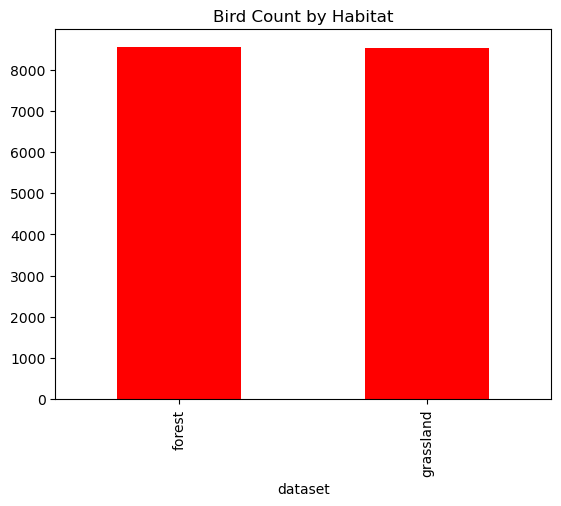

In [219]:
#Visualizing the bird counts by habitat

combined["dataset"].value_counts().plot(kind="bar", title="Bird Count by Habitat",color="red")

In [191]:
#Most common bird species 

combined["common_name"].value_counts().head(10)

common_name
Northern Cardinal          1160
Carolina Wren              1011
Red-eyed Vireo              739
Eastern Tufted Titmouse     728
Indigo Bunting              635
Eastern Wood-Pewee          574
Field Sparrow               542
European Starling           522
American Goldfinch          509
American Robin              496
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 Bird Species'}, ylabel='common_name'>

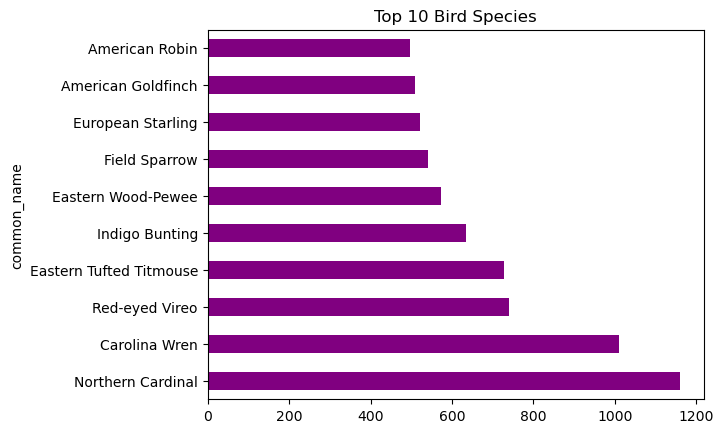

In [194]:
#Top 10 bird species

combined["common_name"].value_counts().head(10).plot(
    kind="barh", title="Top 10 Bird Species",color="purple"
)

In [195]:
# Bird preference (Forest vs Grassland)

bird_pref = combined.groupby(["dataset", "common_name"]).size().reset_index(name="count")
bird_pref.sort_values(by="count", ascending=False).head(10)

,dataset,common_name,count
77,forest,Red-eyed Vireo,694
24,forest,Carolina Wren,646
63,forest,Northern Cardinal,595
168,grassland,Northern Cardinal,565
39,forest,Eastern Tufted Titmouse,541
150,grassland,European Starling,516
151,grassland,Field Sparrow,506
40,forest,Eastern Wood-Pewee,486
162,grassland,Indigo Bunting,485
0,forest,Acadian Flycatcher,436


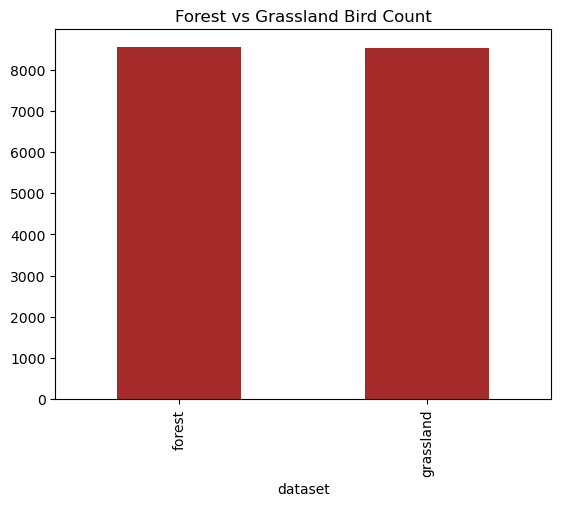

In [220]:
# Visulizing the bird count for forest vs grassland 

import matplotlib.pyplot as plt

combined.groupby("dataset")["common_name"].count().plot(kind="bar",color="brown")
plt.title("Forest vs Grassland Bird Count")
plt.show()

In [199]:
#Sky condition for weather impact

combined.groupby("sky")["common_name"].count().sort_values(ascending=False)

sky
Partly Cloudy          7145
Clear or Few Clouds    5809
Cloudy/Overcast        3097
Fog                     647
Mist/Drizzle            379
Name: common_name, dtype: int64

In [202]:
# Temprature for weather impact

combined.groupby("temperature")["common_name"].count()

temperature
11.000000    21
11.200000     6
11.400000    13
11.600000     4
11.800000     7
             ..
35.099998    15
35.500000     8
35.599998     9
36.200001    11
37.299999    15
Name: common_name, Length: 210, dtype: int64

In [201]:
#Location anlysis

combined.groupby("sheet")["common_name"].count().sort_values(ascending=False)

sheet
ANTI    3921
MONO    3385
PRWI    2463
MANA    2276
CHOH    2202
CATO     805
NACE     684
HAFE     539
GWMP     386
ROCR     289
WOTR     127
Name: common_name, dtype: int64

<Axes: xlabel='common_name'>

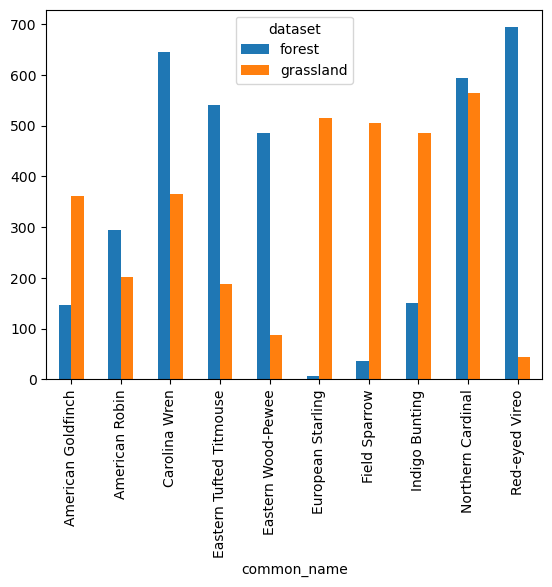

In [205]:
# Top species by habitat

top_species = combined["common_name"].value_counts().head(10).index

df_top = combined[combined["common_name"].isin(top_species)]

df_top.groupby(["common_name", "dataset"]).size().unstack().plot(kind="bar")

<Axes: xlabel='month'>

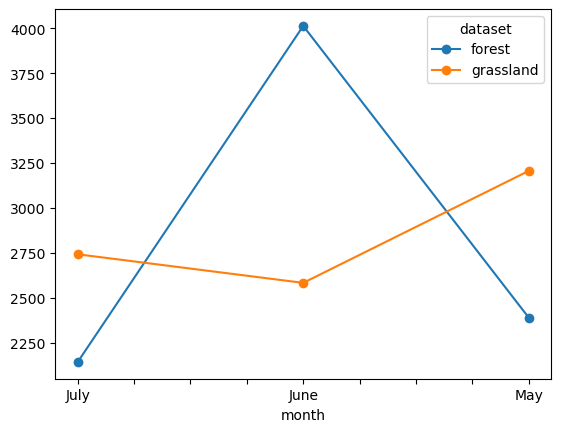

In [206]:
# Monthly trend 

combined["month"] = combined["date"].dt.month_name()

combined.groupby(["month", "dataset"]).size().unstack().plot(kind="line", marker="o")

<Axes: xlabel='temperature'>

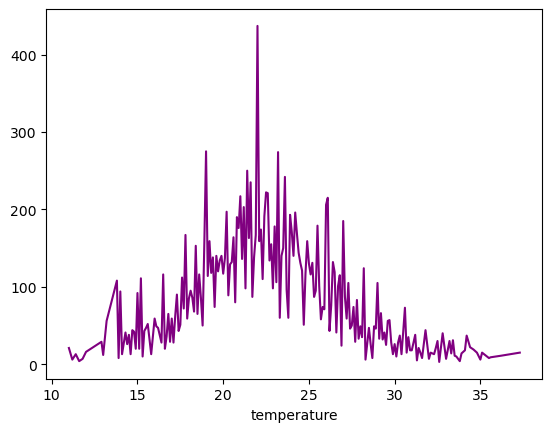

In [221]:
# Temperature vs Bird Activity

combined.groupby("temperature")["common_name"].count().plot(kind="line",color="purple")

<Axes: title={'center': 'Bird Observations by Sky Condition'}, ylabel='sky'>

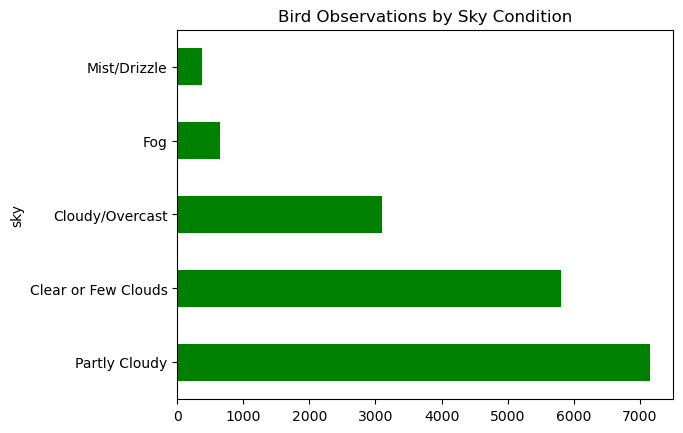

In [222]:
# Sky condition impact on birds 

combined["sky"].value_counts().plot(kind="barh", title="Bird Observations by Sky Condition",color="green")

<Axes: title={'center': 'Bird Observations by Wind'}, ylabel='wind'>

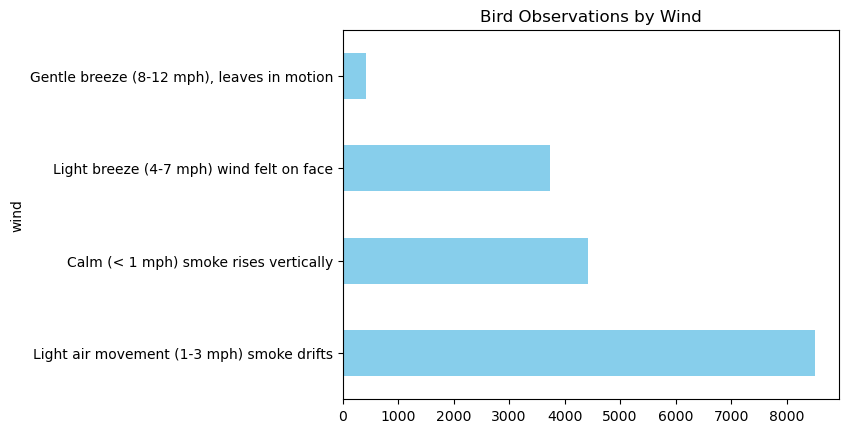

In [224]:
# Wind conditions impact on birds

combined["wind"].value_counts().plot(kind="barh", title="Bird Observations by Wind",color="skyblue")

<Axes: title={'center': 'Top Observers'}, ylabel='observer'>

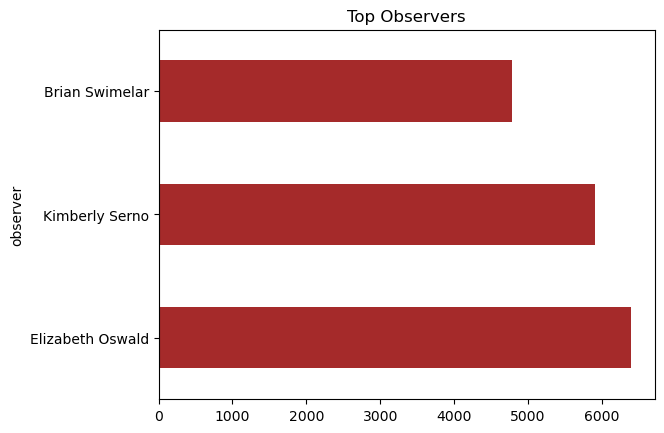

In [225]:
# Top observers 

combined["observer"].value_counts().head(10).plot(kind="barh", title="Top Observers",color="brown")

<Axes: ylabel='sheet'>

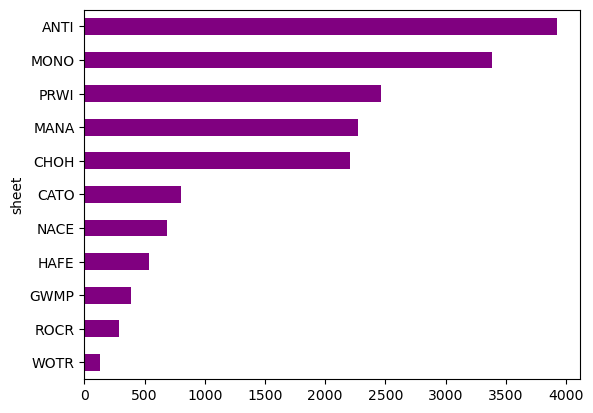

In [226]:
# Location analysis

combined.groupby("sheet")["common_name"].count().sort_values().plot(kind="barh",color="purple")

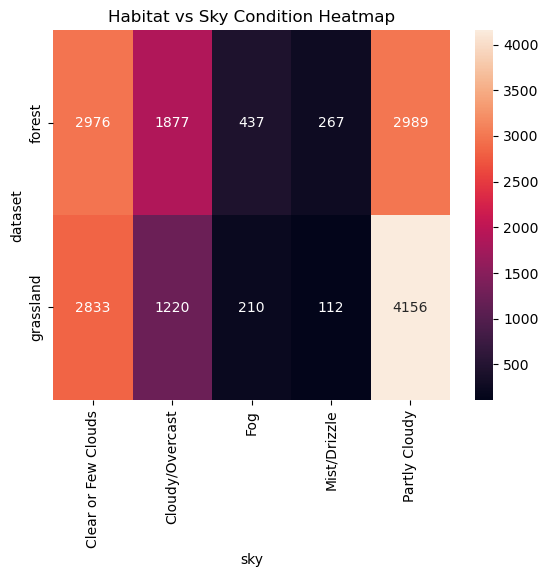

In [213]:
# Heatmap 

import seaborn as sns
import matplotlib.pyplot as plt

pivot = combined.pivot_table(index="dataset", columns="sky", values="common_name", aggfunc="count")

sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Habitat vs Sky Condition Heatmap")
plt.show()

### **Exporting the dataset into mysql**

In [217]:
#Mysql Connection 
from sqlalchemy import create_engine

username = "root"
password = "Peri13"
host = "localhost"
port = "3306"
database = "bird_observation"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

table_name = "bird"
combined.to_sql(table_name, engine, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM bird LIMIT 5;", engine)

,admin_unit_code,site_name,plot_name,location_type,year,date,observer,visit,id_method,flyover_observed,...,humidity,sky,wind,disturbance,initial_three_min_cnt,sheet,previously_obs,dataset,month,temp_bin
0,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,Elizabeth Oswald,1,Singing,0,...,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,1,ANTI,0,forest,May,"(16.26, 21.52]"
1,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,Elizabeth Oswald,1,Calling,0,...,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,1,ANTI,0,forest,May,"(16.26, 21.52]"
2,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,Elizabeth Oswald,1,Calling,0,...,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,ANTI,0,forest,May,"(16.26, 21.52]"
3,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,Elizabeth Oswald,1,Singing,0,...,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,ANTI,0,forest,May,"(16.26, 21.52]"
4,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,Elizabeth Oswald,1,Visualization,0,...,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,0,ANTI,0,forest,May,"(16.26, 21.52]"


### **Saving the merged dataset**

In [230]:
import os

file_path = r"D:\Web_mentix_Internship\Bird_observation_project\cleaned_bird_data.csv"

os.makedirs(folder_path, exist_ok=True)

combined.to_csv(file_path, index=False)

print("File saved successfully!")

File saved successfully!
